# Stage 6 — Statistics



## Setup

In [ ]:
import os, time, gc
import numpy as np, pandas as pd, pyarrow as pa
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.tsa.seasonal import STL
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110

ROOT   = r"D:\Code\projects\Consumer_complaint_analytics"
CLEAN  = os.path.join(ROOT,"data","processed","complaints_clean.parquet")
ML     = os.path.join(ROOT,"data","processed","complaints_ml.parquet")
CHARTS = os.path.join(ROOT,"charts"); REPORTS=os.path.join(ROOT,"reports")
LABELS = ["Credit reporting","Debt collection","Mortgage","Credit card"]
LS     = pd.ArrowDtype(pa.large_string())
EFFECTS = {}   # collect Cramer's V across tests for the final comparison chart

def finish(fig,fname,caption):
    fig.text(0.5,-0.02,caption,ha="center",va="top",fontsize=8.5,style="italic",wrap=True)
    fig.savefig(os.path.join(CHARTS,fname),dpi=130,bbox_inches="tight"); plt.show()

def cramers_v(ct):
    '''chi-square + Cramer's V for a contingency table (DataFrame or array).'''
    a=np.asarray(ct,dtype="float64")
    chi2,p,dof,exp=chi2_contingency(a)
    n=a.sum(); r,k=a.shape
    V=np.sqrt(chi2/(n*(min(r,k)-1)))
    return dict(chi2=chi2,p=p,dof=dof,V=V,n=int(n),expected=exp)

def verdict(V):
    s = "small" if V<0.2 else "moderate" if V<0.4 else "large"
    return f"Cramer's V = {V:.3f} ({s} association)"
print("Setup ready.")

Setup ready.


### Load the structured table

The raw `Company response to consumer` has 9 values. We collapse them into three outcomes that map to a
regulator's question — *did the consumer get a remedy, and what kind?*

- **Monetary relief** — the company gave money back (`Closed with monetary relief`).
- **Non-monetary relief** — the company fixed something without cash, e.g. corrected a credit file
  (`Closed with non-monetary relief`).
- **No relief** — the company responded but gave no remedy: `Closed with explanation` + `Closed without
  relief` + `Closed`.



In [2]:
t=time.time()
df=pd.read_parquet(CLEAN, columns=["category","Company response to consumer","Company","Complaint ID","year_month"])
df["category"]=df["category"].astype("string")
resp=df["Company response to consumer"].astype("string")
MAP3={"Closed with monetary relief":"Monetary relief","Closed with non-monetary relief":"Non-monetary relief",
      "Closed with explanation":"No relief","Closed without relief":"No relief","Closed":"No relief"}
df["outcome3"]=resp.map(MAP3).astype("string")
OUTORDER=["Monetary relief","Non-monetary relief","No relief"]
print(f"Loaded {len(df):,} rows in {time.time()-t:.0f}s")
print("Outcome grouping (incl. excluded):")
print(df["outcome3"].value_counts(dropna=False))
print(f"\nExcluded (open/ambiguous, not tested): {int(df['outcome3'].isna().sum()):,} rows")

Loaded 15,260,793 rows in 17s
Outcome grouping (incl. excluded):


outcome3
No relief              9003491
Non-monetary relief    5392638
<NA>                    758177
Monetary relief         106487
Name: count, dtype: int64[pyarrow]

Excluded (open/ambiguous, not tested): 758,177 rows


## Part 1 — Chi-square tests of independence

### Test A: is the resolution **outcome** associated with the **product category**?

**Null hypothesis:** outcome and category are independent (the outcome mix is the same for every category).
We build the cross-table, run the chi-square test, and report **Cramér's V**.

In [3]:
sub=df.dropna(subset=["outcome3"])
ctA=pd.crosstab(sub["category"],sub["outcome3"]).reindex(index=LABELS,columns=OUTORDER)
rA=cramers_v(ctA); EFFECTS["Outcome x Category"]=rA["V"]
print(ctA, "\n")
print(f"chi-square = {rA['chi2']:,.0f}   dof = {rA['dof']}   p = {rA['p']:.3g}")
print(verdict(rA["V"]), f"  (n = {rA['n']:,})")

outcome3          Monetary relief  Non-monetary relief  No relief
category                                                         
Credit reporting             6435              5075234    7359932
Debt collection              5427               216264     888445
Mortgage                    12911                20665     414917
Credit card                 81714                80475     340197 

chi-square = 2,228,203   dof = 6   p = 0
Cramer's V = 0.277 (moderate association)   (n = 14,502,616)


**Standardized residuals** tell us *where* the association lives. A **standardized residual** is, for
each cell, *(observed − expected) / √expected* — how many "standard units" a cell sits above (+) or below
(−) what independence would predict.

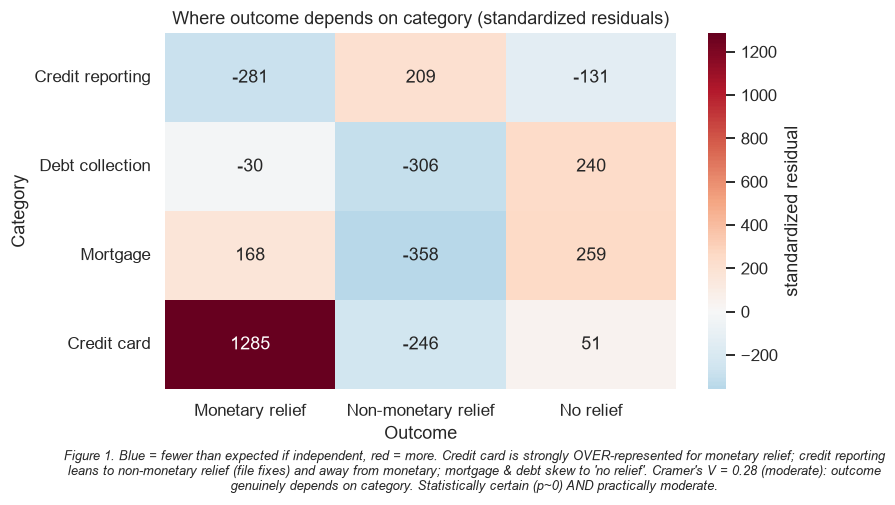

In [4]:
stdres=pd.DataFrame((ctA.values-rA["expected"])/np.sqrt(rA["expected"]),index=ctA.index,columns=ctA.columns)
fig,ax=plt.subplots(figsize=(7.5,4.2))
sns.heatmap(stdres,annot=True,fmt=".0f",cmap="RdBu_r",center=0,ax=ax,cbar_kws={"label":"standardized residual"})
ax.set_title("Where outcome depends on category (standardized residuals)")
ax.set_xlabel("Outcome"); ax.set_ylabel("Category")
finish(fig,"stage6_01_test_a_residuals.png",
       "Figure 1. Blue = fewer than expected if independent, red = more. Credit card is strongly OVER-"
       "represented for monetary relief; credit reporting leans to non-monetary relief (file fixes) and "
       "away from monetary; mortgage & debt skew to 'no relief'. Cramer's V = 0.28 (moderate): outcome "
       "genuinely depends on category. Statistically certain (p~0) AND practically moderate.")

### Why the p-value is almost meaningless here

We take the very same Outcome×Category association and compute it on random subsamples of increasing size.
Here we observe that **Cramér's V stays flat, while the p-value crashes to zero purely
because n grows.**

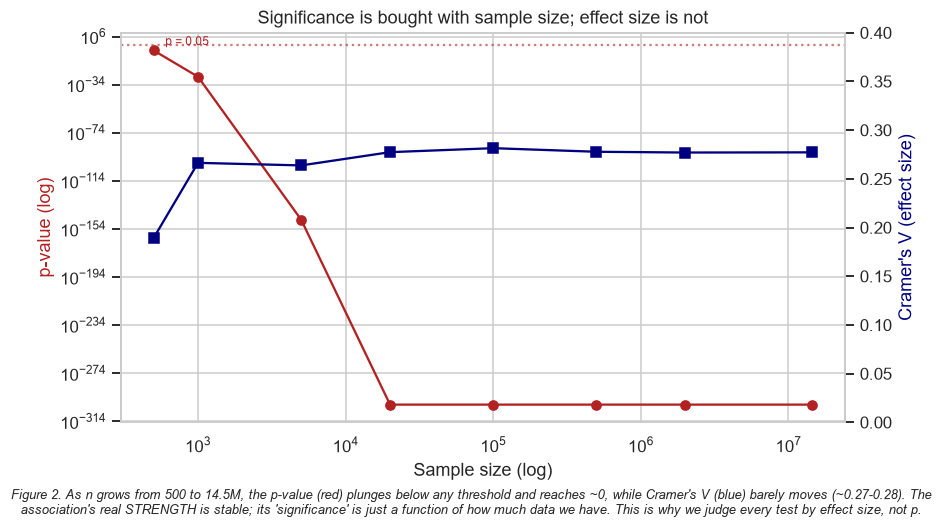

5338

In [5]:
m=df["outcome3"].notna().to_numpy()
catc=pd.factorize(df["category"].to_numpy()[m])[0].astype("int16")
outc=pd.factorize(df["outcome3"].to_numpy()[m])[0].astype("int16")
N=catc.size; rng=np.random.default_rng(42)
sizes=[500,1000,5000,20000,100000,500000,2000000,N]; ps=[]; vs=[]
for n in sizes:
    idx=rng.choice(N,size=min(n,N),replace=False)
    ct=pd.crosstab(pd.Series(catc[idx]),pd.Series(outc[idx]))
    r=cramers_v(ct); ps.append(max(r["p"],1e-300)); vs.append(r["V"])
fig,ax=plt.subplots(figsize=(8.5,4.6))
ax.plot(sizes,ps,marker="o",color="firebrick",label="p-value (left)")
ax.set_yscale("log"); ax.set_xscale("log"); ax.set_xlabel("Sample size (log)")
ax.set_ylabel("p-value (log)",color="firebrick"); ax.axhline(0.05,ls=":",color="firebrick",alpha=0.6)
ax.text(600,0.07,"p = 0.05",color="firebrick",fontsize=8)
ax2=ax.twinx(); ax2.plot(sizes,vs,marker="s",color="navy",label="Cramer's V (right)")
ax2.set_ylabel("Cramer's V (effect size)",color="navy"); ax2.set_ylim(0,0.4); ax2.grid(False)
ax.set_title("Significance is bought with sample size; effect size is not")
finish(fig,"stage6_02_pvalue_vs_n.png",
       "Figure 2. As n grows from 500 to 14.5M, the p-value (red) plunges below any threshold and reaches "
       "~0, while Cramer's V (blue) barely moves (~0.27-0.28). The association's real STRENGTH is stable; "
       "its 'significance' is just a function of how much data we have. This is why we judge every test by "
       "effect size, not p.")
del catc,outc,m; gc.collect()

### Test B: do the three credit bureaus resolve complaints differently?



In [6]:
bureaus={"TRANSUNION INTERMEDIATE HOLDINGS, INC.":"TransUnion","EQUIFAX, INC.":"Equifax",
         "Experian Information Solutions Inc.":"Experian"}
cr=df[df["category"]=="Credit reporting"].copy()
cr["bureau"]=cr["Company"].astype("string").map(bureaus).astype("string")
crb=cr.dropna(subset=["outcome3","bureau"])
ctB=pd.crosstab(crb["bureau"],crb["outcome3"]).reindex(columns=OUTORDER)
rB=cramers_v(ctB); EFFECTS["Outcome x Bureau (within CR)"]=rB["V"]
print(ctB,"\n"); print(f"chi-square={rB['chi2']:,.0f}  dof={rB['dof']}  p={rB['p']:.3g}"); print(verdict(rB["V"]))

# confounded version
topN=df["Company"].astype("string").value_counts().head(10).index
ctBc=pd.crosstab(df.dropna(subset=["outcome3"])["Company"].astype("string").isin(topN),
                 df.dropna(subset=["outcome3"])["outcome3"]).reindex(columns=OUTORDER)
rBc=cramers_v(ctBc); EFFECTS["Outcome x Top-company (CONFOUNDED)"]=rBc["V"]
print(f"\n[confounded] top-10 vs rest: {verdict(rBc['V'])}  <- mixes in the category effect, do not over-read")

outcome3    Monetary relief  Non-monetary relief  No relief
bureau                                                     
Equifax                  53              2047553    2071472
Experian               1047               373118    3056656
TransUnion              573              2515567    1579459 

chi-square=2,093,659  dof=4  p=0
Cramer's V = 0.300 (moderate association)



[confounded] top-10 vs rest: Cramer's V = 0.205 (moderate association)  <- mixes in the category effect, do not over-read


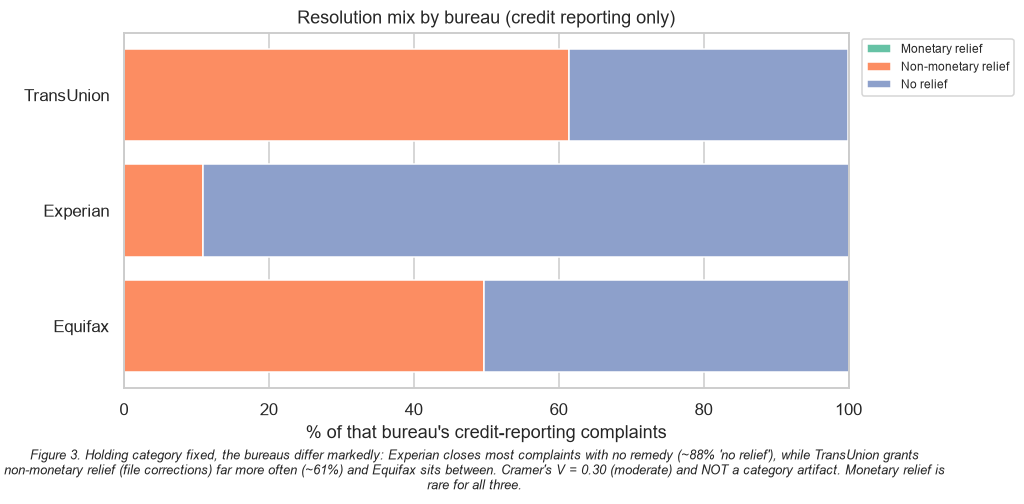

In [7]:
rowpct=pd.crosstab(crb["bureau"],crb["outcome3"],normalize="index").reindex(columns=OUTORDER)*100
fig,ax=plt.subplots(figsize=(8.5,4.2))
left=np.zeros(len(rowpct)); pal=sns.color_palette("Set2",3)
for col,c in zip(OUTORDER,pal):
    ax.barh(rowpct.index,rowpct[col],left=left,label=col,color=c); left+=rowpct[col].values
ax.set_xlim(0,100); ax.set_xlabel("% of that bureau's credit-reporting complaints")
ax.set_title("Resolution mix by bureau (credit reporting only)"); ax.legend(bbox_to_anchor=(1.01,1),loc="upper left",fontsize=8)
finish(fig,"stage6_03_bureau_outcomes.png",
       "Figure 3. Holding category fixed, the bureaus differ markedly: Experian closes most complaints with "
       "no remedy (~88% 'no relief'), while TransUnion grants non-monetary relief (file corrections) far "
       "more often (~61%) and Equifax sits between. Cramer's V = 0.30 (moderate) and NOT a category "
       "artifact. Monetary relief is rare for all three.")

## Part 2 — Time-series decomposition of the credit-reporting surge

In Stage 5, we suspected that the apparent "seasonality" in credit reporting was really the growth trend leaking
in. We now test that hypothesis. **Decomposition** splits the monthly series into **trend** (slow long-run
movement), **seasonal** (a shape that repeats every 12 months), and **residual** (leftover). Because the
series grows almost exponentially, we decompose the **logarithm** of the monthly counts (so the seasonal
part is read as a *percentage* swing) using **STL**, with a
12-month period. We start in 2013 and run through the last complete
month.

In [8]:
crm=df[df["category"]=="Credit reporting"].groupby("year_month").size().sort_index()
crm.index=pd.PeriodIndex(crm.index,freq="M").to_timestamp()
crm=crm[crm.index>=pd.Timestamp("2013-01-01")]
print("series:",crm.index.min().date(),"->",crm.index.max().date(),"| last 3 months:",crm.tail(3).to_dict())
logs=np.log(crm.astype(float))
res=STL(logs,period=12,robust=True).fit()
growth=np.exp(res.trend.iloc[-1]-res.trend.iloc[0])
sf_month=pd.Series(np.exp(res.seasonal.values),index=res.seasonal.index).groupby(lambda d:d.month).mean()
p2t=(sf_month.max()/sf_month.min()-1)*100   # month-averaged (stable) peak-to-trough
print(f"Trend growth over period: ~{growth:,.0f}x")
print(f"Seasonal peak-to-trough swing (month-averaged): ~{p2t:.0f}%  (vs ~{growth:,.0f}x trend -> trend dominates)")

series: 2013-01-01 -> 2026-06-01 | last 3 months: {Timestamp('2026-04-01 00:00:00'): 563919, Timestamp('2026-05-01 00:00:00'): 593780, Timestamp('2026-06-01 00:00:00'): 630010}
Trend growth over period: ~731x
Seasonal peak-to-trough swing (month-averaged): ~23%  (vs ~731x trend -> trend dominates)


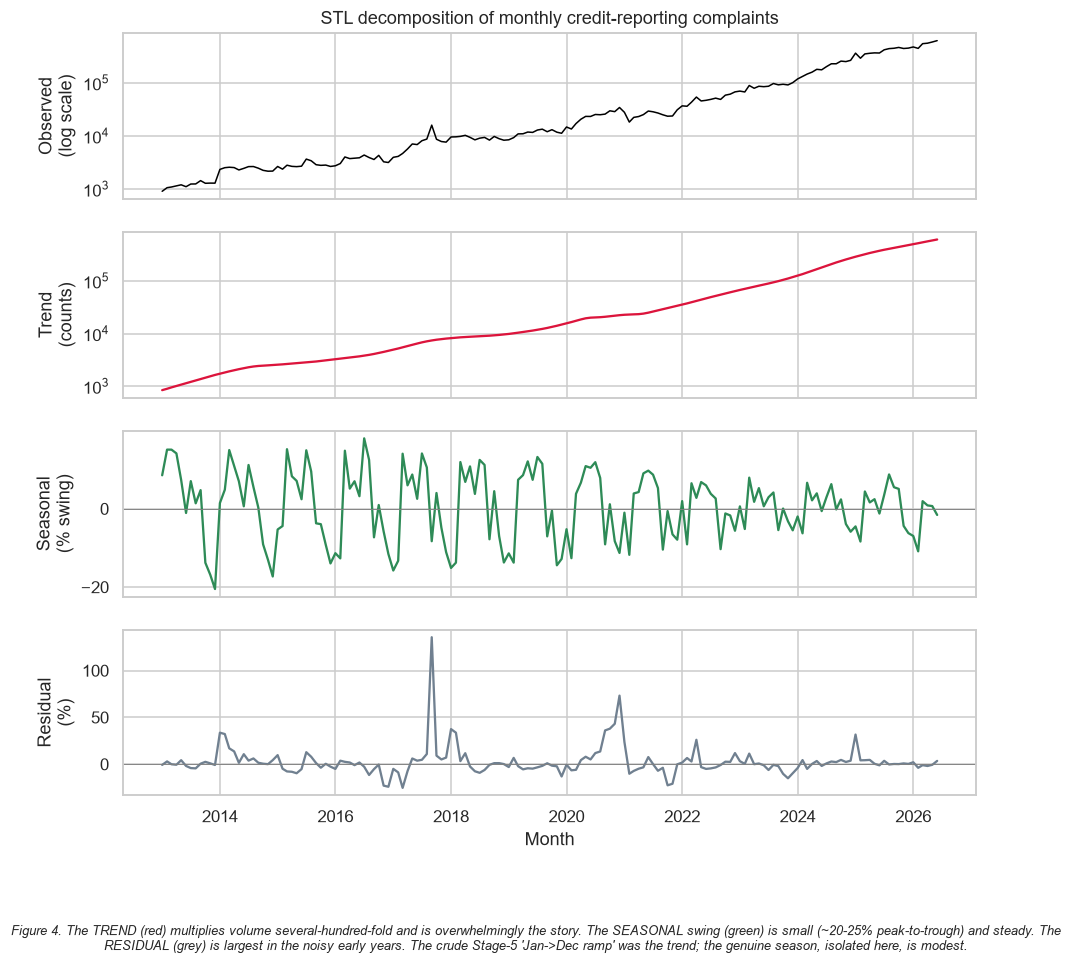

In [9]:
fig,axes=plt.subplots(4,1,figsize=(10,9),sharex=True)
axes[0].plot(crm.index,crm.values,color="black",lw=1); axes[0].set_yscale("log")
axes[0].set_ylabel("Observed\n(log scale)"); axes[0].set_title("STL decomposition of monthly credit-reporting complaints")
axes[1].plot(res.trend.index,np.exp(res.trend),color="crimson"); axes[1].set_yscale("log"); axes[1].set_ylabel("Trend\n(counts)")
axes[2].plot(res.seasonal.index,(np.exp(res.seasonal)-1)*100,color="seagreen"); axes[2].axhline(0,color="grey",lw=.6); axes[2].set_ylabel("Seasonal\n(% swing)")
axes[3].plot(res.resid.index,(np.exp(res.resid)-1)*100,color="slategrey"); axes[3].axhline(0,color="grey",lw=.6); axes[3].set_ylabel("Residual\n(%)"); axes[3].set_xlabel("Month")
finish(fig,"stage6_04_decomposition.png",
       "Figure 4. The TREND (red) multiplies volume several-hundred-fold and is overwhelmingly the story. "
       "The SEASONAL swing (green) is small (~20-25% peak-to-trough) and steady. The RESIDUAL (grey) is "
       "largest in the noisy early years. The crude Stage-5 'Jan->Dec ramp' was the trend; the genuine "
       "season, isolated here, is modest.")

The **seasonal component on its own** (averaged by calendar month) shows the genuine recurring
pattern once the trend is stripped out.

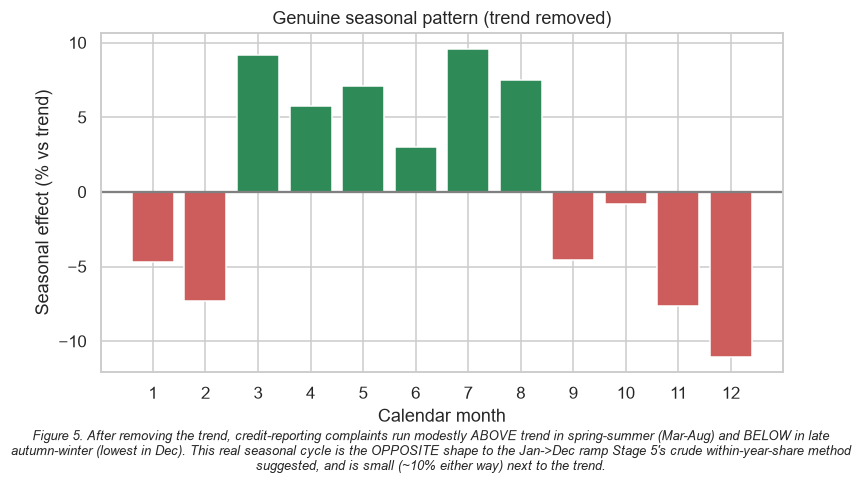

In [10]:
sf=pd.Series(np.exp(res.seasonal.values),index=res.seasonal.index).groupby(lambda d:d.month).mean()
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(sf.index,(sf.values-1)*100,color=["seagreen" if v>=1 else "indianred" for v in sf.values])
ax.axhline(0,color="grey"); ax.set_xticks(range(1,13)); ax.set_xlabel("Calendar month")
ax.set_ylabel("Seasonal effect (% vs trend)"); ax.set_title("Genuine seasonal pattern (trend removed)")
finish(fig,"stage6_05_seasonal_factors.png",
       "Figure 5. After removing the trend, credit-reporting complaints run modestly ABOVE trend in "
       "spring-summer (Mar-Aug) and BELOW in late autumn-winter (lowest in Dec). This real seasonal cycle "
       "is the OPPOSITE shape to the Jan->Dec ramp Stage 5's crude within-year-share method suggested, and "
       "is small (~10% either way) next to the trend.")

### Free and reload for the join

Part 3 joins text-derived templating to outcomes, so we free the big table and reload only the keys needed.

In [11]:
del df, sub, cr, crb, crm; gc.collect()

4038

## Part 3 — Do templated "dispute-mill" complaints get resolved differently?

We flag each **credit-reporting complaint that carries a narrative** as
**templated** or **unique**, then join that flag to the complaint's outcome via `Complaint ID`.



In [12]:
t=time.time()
ml=pd.read_parquet(ML,columns=["Complaint ID","narrative_clean"],filters=[("category","==","Credit reporting")])
ml["narrative_clean"]=ml["narrative_clean"].astype(LS)
codes,_=pd.factorize(ml["narrative_clean"])
ml["templated"]=np.bincount(codes)[codes]>=2
ml=ml[["Complaint ID","templated"]].dropna(subset=["Complaint ID"])
clean2=pd.read_parquet(CLEAN,columns=["Complaint ID","category","Company response to consumer"])
clean2=clean2[clean2["category"]=="Credit reporting"]
resp2=clean2["Company response to consumer"].astype("string")
MAP4={**MAP3,"Closed with explanation":"Explanation only","Closed without relief":"No relief (other)","Closed":"No relief (other)"}
g=ml.merge(clean2[["Complaint ID"]].assign(resp=resp2.values),on="Complaint ID",how="inner")
g["outcome3"]=g["resp"].map(MAP3).astype("string")
g["outcome4"]=g["resp"].map(MAP4).astype("string")
g["tlabel"]=np.where(g["templated"],"Templated","Unique")
del ml,clean2; gc.collect()
print(f"Joined {len(g):,} credit-reporting narrative complaints to outcomes in {time.time()-t:.0f}s")

Joined 2,509,783 credit-reporting narrative complaints to outcomes in 17s


In [13]:
ga=g.dropna(subset=["outcome3"])
ct3=pd.crosstab(ga["tlabel"],ga["outcome3"]).reindex(index=["Templated","Unique"],columns=OUTORDER)
r3=cramers_v(ct3); EFFECTS["Outcome x Templated (CR narratives)"]=r3["V"]
row3=pd.crosstab(ga["tlabel"],ga["outcome3"],normalize="index").reindex(index=["Templated","Unique"],columns=OUTORDER)*100
print(ct3,"\n"); print("row %:\n",row3.round(2),"\n")
print(f"chi-square={r3['chi2']:,.0f}  dof={r3['dof']}  p={r3['p']:.3g}"); print(verdict(r3["V"]))
print(f"\nMonetary-relief rate: Templated {row3.loc['Templated','Monetary relief']:.3f}%  vs  "
      f"Unique {row3.loc['Unique','Monetary relief']:.3f}%")

outcome3   Monetary relief  Non-monetary relief  No relief
tlabel                                                    
Templated              254               765751     909876
Unique                3067               264620     564246 

row %:
 outcome3   Monetary relief  Non-monetary relief  No relief
tlabel                                                    
Templated             0.02                45.69      54.29
Unique                0.37                31.81      67.82 

chi-square=48,649  dof=2  p=0
Cramer's V = 0.139 (small association)

Monetary-relief rate: Templated 0.015%  vs  Unique 0.369%


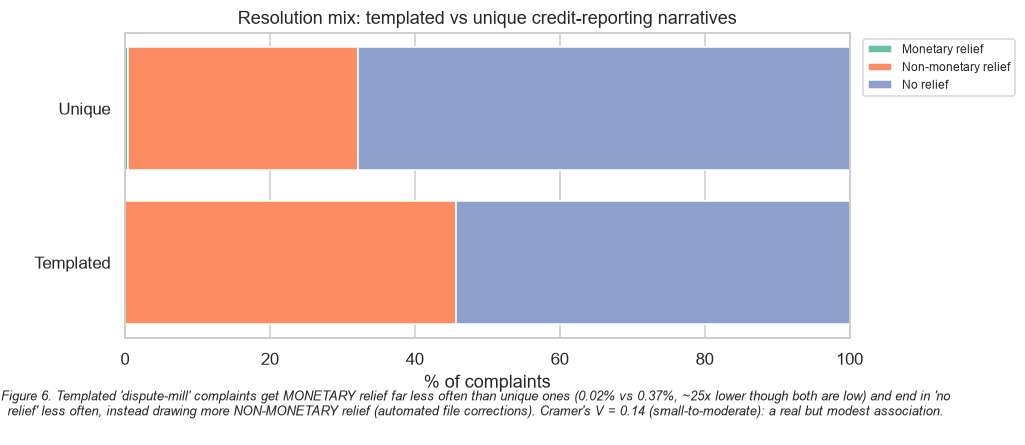

In [14]:
fig,ax=plt.subplots(figsize=(8.5,3.6))
left=np.zeros(len(row3)); pal=sns.color_palette("Set2",3)
for col,c in zip(OUTORDER,pal):
    ax.barh(row3.index,row3[col],left=left,label=col,color=c); left+=row3[col].values
ax.set_xlim(0,100); ax.set_xlabel("% of complaints"); ax.set_title("Resolution mix: templated vs unique credit-reporting narratives")
ax.legend(bbox_to_anchor=(1.01,1),loc="upper left",fontsize=8)
finish(fig,"stage6_06_templated_outcomes.png",
       "Figure 6. Templated 'dispute-mill' complaints get MONETARY relief far less often than unique ones "
       "(0.02% vs 0.37%, ~25x lower though both are low) and end in 'no relief' less often, instead "
       "drawing more NON-MONETARY relief (automated file corrections). Cramer's V = 0.14 (small-to-"
       "moderate): a real but modest association.")

### Robustness check — does treating `Closed with explanation` separately change the conclusion?

We re-run the templated test with `Closed with explanation` as **its own** category instead of folding it
into "No relief," to confirm our headline doesn't hinge on that one interpretive choice.

In [15]:
gb=g.dropna(subset=["outcome4"])
ct4=pd.crosstab(gb["tlabel"],gb["outcome4"])
r4=cramers_v(ct4)
print(ct4,"\n")
print(f"3-level outcome:  Cramer's V = {r3['V']:.4f}")
print(f"4-level (explanation separate):  Cramer's V = {r4['V']:.4f}")
print("=> Effect size and direction are essentially unchanged -> the conclusion is ROBUST to this choice.")
del g,ga,gb; gc.collect()

outcome4   Explanation only  Monetary relief  No relief (other)  \
tlabel                                                            
Templated            909866              254                 10   
Unique               564162             3067                 84   

outcome4   Non-monetary relief  
tlabel                          
Templated               765751  
Unique                  264620   

3-level outcome:  Cramer's V = 0.1393
4-level (explanation separate):  Cramer's V = 0.1394
=> Effect size and direction are essentially unchanged -> the conclusion is ROBUST to this choice.


3486

## Effect-size comparison

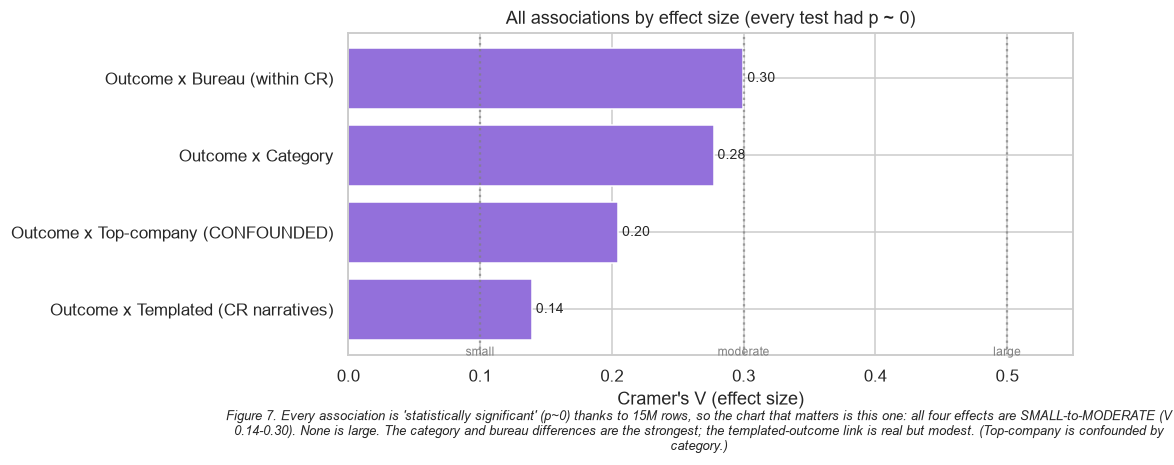

Outcome x Bureau (within CR)           0.300
Outcome x Category                     0.277
Outcome x Top-company (CONFOUNDED)     0.205
Outcome x Templated (CR narratives)    0.139
dtype: float64

In [16]:
order=["Outcome x Bureau (within CR)","Outcome x Category","Outcome x Top-company (CONFOUNDED)","Outcome x Templated (CR narratives)"]
ev=pd.Series({k:EFFECTS[k] for k in order if k in EFFECTS})
fig,ax=plt.subplots(figsize=(8.5,3.8))
bars=ax.barh(ev.index[::-1],ev.values[::-1],color="mediumpurple")
for thr,lab in [(0.1,"small"),(0.3,"moderate"),(0.5,"large")]:
    ax.axvline(thr,ls=":",color="grey",alpha=0.7); ax.text(thr,-0.6,lab,fontsize=8,color="grey",ha="center")
ax.set_xlim(0,0.55); ax.set_xlabel("Cramer's V (effect size)")
ax.set_title("All associations by effect size (every test had p ~ 0)")
for b,v in zip(bars,ev.values[::-1]): ax.text(v,b.get_y()+b.get_height()/2,f" {v:.2f}",va="center",fontsize=9)
finish(fig,"stage6_07_cramers_v_comparison.png",
       "Figure 7. Every association is 'statistically significant' (p~0) thanks to 15M rows, so the chart "
       "that matters is this one: all four effects are SMALL-to-MODERATE (V 0.14-0.30). None is large. "
       "The category and bureau differences are the strongest; the templated-outcome link is real but "
       "modest. (Top-company is confounded by category.)")
ev.round(3)

In [ ]:
L=[]
L.append("STAGE 6 - STATISTICS - SUMMARY"); L.append("="*42)
L.append("CENTREPIECE: at ~15M rows every chi-square p-value is ~0, so significance is automatic and")
L.append("uninformative. We judge each test by EFFECT SIZE (Cramer's V). Rule of thumb: 0.1 small, 0.3 moderate, 0.5 large.")
L.append("")
L.append("PART 1 - chi-square tests of independence:")
L.append(f"  A. Outcome x Category:            V={EFFECTS['Outcome x Category']:.3f} (moderate). Credit card over-represented for")
L.append("     monetary relief; credit reporting -> non-monetary (file fixes); mortgage/debt -> no relief.")
L.append(f"  B. Outcome x Bureau (within CR):  V={EFFECTS['Outcome x Bureau (within CR)']:.3f} (moderate), category held fixed. Experian closes")
L.append("     ~88% with no remedy; TransUnion grants non-monetary relief ~61%; Equifax between.")
L.append(f"  B(confounded) top-10 vs rest:     V={EFFECTS['Outcome x Top-company (CONFOUNDED)']:.3f} - mixes in the category effect; do not over-read.")
L.append("  Demonstration: Cramer's V is flat (~0.28) across sample sizes while p collapses to 0 - significance is bought with n.")
L.append("")
L.append("PART 2 - STL decomposition of monthly credit-reporting volume (log scale, period 12, 2013->last complete month):")
L.append(f"  Trend multiplies volume ~{growth:,.0f}x and dominates utterly. Genuine seasonal swing ~{p2t:.0f}% peak-to-trough,")
L.append("  ABOVE trend in spring-summer, lowest in Dec - the OPPOSITE of Stage 5's crude Jan->Dec ramp, which was just the trend.")
L.append("  => Stage 5's suspicion CONFIRMED: the 'seasonality' it saw was the growth trend; the real season is small.")
L.append("")
L.append("PART 3 - templated vs unique credit-reporting NARRATIVE complaints x outcome (denominator: CR complaints WITH a narrative):")
L.append(f"  V={EFFECTS['Outcome x Templated (CR narratives)']:.3f} (small-to-moderate). Monetary relief: templated 0.02% vs unique 0.37% (~25x lower).")
L.append("  Templated draw MORE non-monetary relief (45.7% vs 31.8%) and LESS 'no relief' (54.3% vs 67.8%).")
L.append("  ROBUSTNESS: treating 'Closed with explanation' as its own category leaves V unchanged (0.139 -> 0.139) -> conclusion robust.")
L.append("")
L.append("HONEST FLAGS:")
L.append("  - 'Closed with explanation' (~9M) grouped as 'No relief' is a substantive choice; Part 3 robustness shows it doesn't change conclusions.")
L.append("  - Effect sizes are small-to-moderate, NOT large: associations are real but should not be overstated for policy.")
L.append("  - Part 3 is over the narrative subset only; templated effect is modest (V=0.14) - reported as such, not inflated.")
L.append("  - Cramer's V thresholds are rules of thumb; exact bands depend on table dimensions.")
S="\n".join(L)
with open(os.path.join(REPORTS,"stage6_summary.txt"),"w",encoding="utf-8") as f: f.write(S)
print(S)

STAGE 6 - ADVANCED STATISTICS - SUMMARY
CENTREPIECE: at ~15M rows every chi-square p-value is ~0, so significance is automatic and
uninformative. We judge each test by EFFECT SIZE (Cramer's V). Rule of thumb: 0.1 small, 0.3 moderate, 0.5 large.

PART 1 - chi-square tests of independence:
  A. Outcome x Category:            V=0.277 (moderate). Credit card over-represented for
     monetary relief; credit reporting -> non-monetary (file fixes); mortgage/debt -> no relief.
  B. Outcome x Bureau (within CR):  V=0.300 (moderate), category held fixed. Experian closes
     ~88% with no remedy; TransUnion grants non-monetary relief ~61%; Equifax between.
  B(confounded) top-10 vs rest:     V=0.205 - mixes in the category effect; do not over-read.
  Demonstration: Cramer's V is flat (~0.28) across sample sizes while p collapses to 0 - significance is bought with n.

PART 2 - STL decomposition of monthly credit-reporting volume (log scale, period 12, 2013->last complete month):
  Trend multiplie